# Pacotes

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import boxcox
from sklearn.tree import DecisionTreeRegressor, plot_tree
#import math
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, \
    confusion_matrix, balanced_accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score,f1_score
import pyarrow
import pickle
#import shap

# Conversão do csv para parquet



Arquivos Parquet, normalmente ocupa menos espaço em disco que o formato csv e, por isso, é indicado quando se lida com grande volume de dados.

Esse arquivo, especificamente, ocupa 1,65GB no formato csv e, 416 MB no formato parquet.

O formato parquet foi desenvolvido pelo Apache e o dados são salvos em colunas. Ao contrário do formato CSV, o formato parquet salva as colunas separadamente e carrega apenas as colunas que serão utilizadas. Esse formato é indicado para ambiente de big data e datalakes e, é compatível com Apache Spark, Hive, AWS Athena, Google BigQuery e Pandas.

In [ ]:
# #Encontra o encoding do arquivo csv
# import chardet

# with open("G:\Meu Drive\ciencia de dados\Pos\TCC\TCC\dados\enem\microdados_enem_2023\DADOS\MICRODADOS_ENEM_2023.csv", 'rb') as f:
#     result = chardet.detect(f.read(1000))  # Lê todo o arquivo para detectar a codificação

# print(result)  # Exibe a codificação detectada

In [ ]:
#Banco de dados real, completo
#df = pd.read_csv("G:\Meu Drive\ciencia de dados\Pos\TCC\TCC\dados\enem\microdados_enem_2023\DADOS\MICRODADOS_ENEM_2023.csv", encoding= 'ISO-8859-1', sep=';')


In [ ]:
# #Salva df no formato parque com o nome enem_2023.parquet
# df.to_parquet('enem_2023.parquet')

In [ ]:
# df.shape

# Carregamento dos dados

In [3]:
#Amostra dos dados usandos para criar o algoritmo
#df_enem_2023=pd.read_csv("G:\Meu Drive\ciencia de dados\Pos\TCC\TCC\dados\enem\microdados_enem_2023\DADOS\MICRODADOS_ENEM_2023.csv", encoding= 'ISO-8859-1', sep=';', nrows=400)

In [4]:
# Dados que serão usados no TCC
df_enem_2023 = pd.read_parquet("C://Users//prisc//Documents//enem_2023.parquet")


In [5]:
df_enem_2023.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,...,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,210059085136,2023,14,M,2,1,1,1,17,1,...,C,C,B,B,A,B,B,A,A,B
1,210059527735,2023,12,M,2,1,0,1,16,1,...,B,A,B,B,A,A,C,A,D,B
2,210061103945,2023,6,F,1,1,1,1,0,1,...,B,A,A,B,A,A,A,A,A,B
3,210060214087,2023,2,F,1,3,1,2,0,2,...,A,A,A,B,A,A,D,A,A,B
4,210059980948,2023,3,F,1,3,1,2,0,2,...,A,A,A,B,A,A,B,A,A,A


In [6]:
df_enem_2023.shape

(3933955, 76)

# Ensemble Models

Algoritmos de Ensemble, combinam vários modelos de machibe learning para tornar um modelos com maior precisão e robustez.

Os pricipais modelos de ensemble são:
* Bagging: Cria modelos diferentes para cada amostra, com reposição, de dados. A previsão final é baseada na média das previsões, para modelos de regressão, ou por maioria de votos, para modelos de classificação.
* Boosting: É criado um modelo e, a partir dos erros do modelo criado, é criado um novo modelo melhorado. Esse processo ocorre várias vezes e em cada modelo ocorre a tentativa de corrigir os erros do modelo anterior.
* Stacking: Treina múltiplos modelos diferentes e depois usa um modelo final para combinar a revisão de todos os modelos.

Os algoritmos de emsemble que serão usados são:
* Random Forest.
* Light GBM.
* XG Boosting.

Com o intuito de comparar os modelos, será criado um dicionário para armazenar a acurácia, a acurácia balanceada, o AUC e o GINI de cada modelo treinado.

In [115]:
#Dicionário para armazenar métricas de eficácia dos modelos
dict_modelos={'Modelo': [], 'Acuracia': [], 'Acuracia Balanceada': [],  'AUC': [], 'GINI': []}

## Dados de Treino e Teste

Os dados serão separados em duas partes:
* 80% de dados de treino
* 20% dos dados de teste

Os dados de treino são usados para identificar padrões no comportamento dos dados.
Os dados de teste são usados para validar os padrões que foram encontrados nos dados de treino.

O conjunto de dados, é desbalanceado, no que diz a respeito do total de candidatos que tiraram nota de matemática acima do percentil 80. Para manter a proporção entre esses candidatos ao separar os dados de treino e de teste, será usada a técnica de estratificação dos dados. Isso garante que nos dados de treino e de teste se mantenham a mesma proporção de candidatos que tiraram boas notas de matemática, que os dados totais.

In [116]:
presentes_df_enem_2023_dummies.columns

Index(['INSCRICAO', 'IS_TOP20', 'FAIXA_ETARIA_18', 'FAIXA_ETARIA_19',
       'FAIXA_ETARIA_20', 'FAIXA_ETARIA_21', 'FAIXA_ETARIA_22',
       'FAIXA_ETARIA_23', 'FAIXA_ETARIA_24', 'FAIXA_ETARIA_25',
       'FAIXA_ETARIA_26_30', 'FAIXA_ETARIA_31_35', 'FAIXA_ETARIA_36_40',
       'FAIXA_ETARIA_41_45', 'FAIXA_ETARIA_46_50', 'FAIXA_ETARIA_51_55',
       'FAIXA_ETARIA_56_60', 'FAIXA_ETARIA_61_65', 'FAIXA_ETARIA_66_70',
       'FAIXA_ETARIA_maior_que_70', 'FAIXA_ETARIA_menor_que_17',
       'SEXO_Masculino', 'COR_Branca', 'COR_Indígena', 'COR_Nao_declarado',
       'COR_Parda', 'COR_Preta',
       'NACIONALIDADE_Brasileiro_Nato_nascido_no_exterior',
       'NACIONALIDADE_Brasileiro_Naturalizado', 'NACIONALIDADE_Estrangeiro',
       'NACIONALIDADE_Nao_informado', 'REGIAO_Nordeste', 'REGIAO_Norte',
       'REGIAO_Sudeste', 'REGIAO_Sul', 'REGIAO_Desconhecido',
       'ADM_ESC_Privada', 'ADM_ESC_Publica', 'ADM_ESC_Desconhecido',
       'TP_URBANA_RURAL_urbana', 'TP_URBANA_RURAL_Desconhecido',
   

Criação do dataframe X com as features explicativas

In [117]:
presentes_df_enem_2023.columns

Index(['INSCRICAO', 'FAIXA_ETARIA', 'SEXO', 'ESTADO_CIVIL', 'COR',
       'NACIONALIDADE', 'ST_CONCLUSAO', 'ANO_CONCLUSAO', 'MUNICIPIO', 'UF',
       'ADM_ESC', 'TP_URBANA_RURAL', 'TP_PRESENCA_CH', 'TP_PRESENCA_MT',
       'NOTA_CN', 'NOTA_CH', 'NOTA_LC', 'NOTA_MT', 'NOTA_COMP1_REDACAO',
       'NOTA_COMP2_REDACAO', 'NOTA_COMP3_REDACAO', 'NOTA_COMP4_REDACAO',
       'NOTA_COMP5_REDACAO', 'NOTA_REDACAO', 'ESCOLARIDADE_PATERNA',
       'ESCOLARIDADE_MATERNA', 'RENDA_FAMILIAR', 'POSSUI_DIARISTA',
       'QTD_BANHEIROS', 'QTD_CARROS', 'QTD_GELADEIRA', 'QTD_TV_COLORIDA',
       'QTD_COMPUTADOR', 'ACESSO_INTERNET', 'REGIAO', 'MEDIA', 'IS_TOP20'],
      dtype='object')

In [118]:
# Criação das dataframe com as features explicativas
X=presentes_df_enem_2023[[ 'FAIXA_ETARIA', 'SEXO', 'ESTADO_CIVIL', 'COR',
       'NACIONALIDADE', 'ST_CONCLUSAO', 'ANO_CONCLUSAO', 'UF',
       'ADM_ESC', 'TP_URBANA_RURAL' , 'ESCOLARIDADE_PATERNA',
       'ESCOLARIDADE_MATERNA', 'RENDA_FAMILIAR', 'REGIAO']]

In [ ]:
# X=presentes_df_enem_2023.drop(columns = ['INSCRICAO', 'POSSUI_DIARISTA', 'QTD_BANHEIROS', 'QTD_CARROS',
#        'QTD_GELADEIRA', 'QTD_TV_COLORIDA', 'QTD_COMPUTADOR', 'ACESSO_INTERNET','PRESENCA_CH_LC', 'PRESENCA_MT_CN',
#        'NOTA_CN', 'NOTA_CH', 'NOTA_LC', 'NOTA_MT', 'NOTA_COMP1_REDACAO',
#        'NOTA_COMP2_REDACAO', 'NOTA_COMP3_REDACAO', 'NOTA_COMP4_REDACAO',
#        'NOTA_COMP5_REDACAO', 'NOTA_REDACAO','MEDIA',
#        'IS_TOP20'])

In [119]:
# Criação do dataframe com as features explicativas dumizadas
X_dum = presentes_df_enem_2023_dummies.drop(columns = ['INSCRICAO','IS_TOP20'])

In [120]:
# Criação do dataframe com apenas a variável target 'IS_TOP20'
y=presentes_df_enem_2023['IS_TOP20']

In [121]:
# Separação dos dados de treino e teste na proporção de 80% são para treinar os modelos e 20% são para testar o modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [122]:
# Separação dos dados de treino e teste, dos dados dumizados, na proporção de 80% são para treinar os modelos e 20% são para testar o modelo
X_train_dum, X_test_dum, y_train_dum, y_test_dum = train_test_split(X_dum, y, test_size=0.2, random_state=42, stratify=y)

In [123]:
# Contagem dos dados de treino em cada categoria
y_train.value_counts()

IS_TOP20
0    1386081
1     347393
Name: count, dtype: int64

In [ ]:
# Confirmação dos tipos de dados no conjunto de treino
X_train.info()

## Random Forest

Seráo separadoas vários subconjuntos aleatórios de dados e, um subconjunto aleatódio de variáveis e, para cada subconjunto será treinado um modelo de árvore de decisão.
Para cada modelo, cada observação receberá uma classificação como positiva ou negativa.
As observações que receberaão a maioria dos votos como positiva, serão classificadas como positivas, caso contrário, serão classificadas como negativa.

In [124]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1733474 entries, 1154687 to 445991
Data columns (total 14 columns):
 #   Column                Dtype   
---  ------                -----   
 0   FAIXA_ETARIA          category
 1   SEXO                  category
 2   ESTADO_CIVIL          category
 3   COR                   category
 4   NACIONALIDADE         category
 5   ST_CONCLUSAO          category
 6   ANO_CONCLUSAO         int64   
 7   UF                    category
 8   ADM_ESC               category
 9   TP_URBANA_RURAL       category
 10  ESCOLARIDADE_PATERNA  category
 11  ESCOLARIDADE_MATERNA  category
 12  RENDA_FAMILIAR        category
 13  REGIAO                category
dtypes: category(13), int64(1)
memory usage: 47.9 MB


In [128]:
# Criação do modelo 'modelo_rf' de Random Forest base, treinando 50 árvores de decisão
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train_dum, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [153]:
import joblib
joblib.dump(modelo_rf, 'modelo_rf.pkl')

['modelo_rf.pkl']

In [134]:
len(y_train)

1733474

In [129]:
# Valores previstos usando o modelo base de random forest (modelo_rf)
y_pred_modelo_rf = modelo_rf.predict(X_test_dum)
y_pred_modelo_rf

array([0, 0, 0, ..., 0, 0, 1], shape=(433369,))

In [135]:
# Valores reais da target
y_test

1578576    0
111489     1
2034119    0
290839     1
302016     0
          ..
453169     0
1530046    0
1261997    0
1271063    1
952469     0
Name: IS_TOP20, Length: 433369, dtype: int64

In [136]:
# Probabilidade de ocorrer o evento estar entre os top20 dos dados de treino e de teste
p_test = modelo_rf.predict_proba(X_test_dum)[:, 1]
p_train = modelo_rf.predict_proba(X_train_dum)[:, 1]

In [137]:
p_test

array([0.07955573, 0.46122153, 0.14321117, ..., 0.14750228, 0.40074861,
       0.86742207], shape=(433369,))

Observe que é considerado que o evento 'estar entre os top20' ocorre, se a probabilidade disso ocorrer for maior que 50%

### Avaliando o 1º modelo (modelo base de random forest)

A curva ROC é a curva obtida a partir do seguinte processo:
Calcula-se as probabilidades do evento ocorrer (p_test) e verifica se os valores reais (y_test) estão corretos para vários thresholds. Para cada threshold, calcula-se TPR e FPR, e coloca os dados obtidos no gráfico. Esse gráfico é chamado curva ROC, e a área sob o gráfico é chamado AUC.

In [138]:
# Calculando acurácia e matriz de confusão
cm_rf = confusion_matrix(y_test, y_pred_modelo_rf)
ac_rf = accuracy_score(y_test, y_pred_modelo_rf)
bac_rf = balanced_accuracy_score(y_test, y_pred_modelo_rf)
auc_score_rf = roc_auc_score(y_test, p_test)

In [139]:
dict_modelos={'Modelo': [], 'Acuracia': [], 'Acuracia Balanceada': [],  'AUC': [], 'GINI': []}

In [140]:
dict_modelos['Modelo'].append('1ª Random Forest')
dict_modelos['Acuracia'].append(ac_rf)
dict_modelos['Acuracia Balanceada'].append(bac_rf)
dict_modelos['AUC'].append(auc_score_rf)
dict_modelos['GINI'].append(2*auc_score_rf-1)

In [141]:
dict_modelos

{'Modelo': ['1ª Random Forest'],
 'Acuracia': [0.8221123338309847],
 'Acuracia Balanceada': [0.64862768067648],
 'AUC': [0.7922785367647159],
 'GINI': [0.5845570735294319]}

In [147]:
pd.DataFrame(dict_modelos)

,Modelo,Acuracia,Acuracia Balanceada,AUC,GINI
0,1ª Random Forest,0.822112,0.648628,0.792279,0.584557


#### Curva ROC do modelo base

In [148]:
# Calcula o AUC dos dados de treino e de teste para comparar o modelo
auc_train = roc_auc_score(y_train, p_train)
auc_test = roc_auc_score(y_test, p_test)

In [149]:
# Calcula a taxa dos verdadeiros positivos, e a taxa de falsos positivos dos dados de treino e de teste para 
# comparar o modelo

fpr_train, tpr_train, _ = roc_curve(y_train, p_train)
fpr_test, tpr_test, _ = roc_curve(y_test, p_test)


In [150]:
# Gerar a Curva ROC    
fpr_train_rf, tpr_train_rf, _ = roc_curve(y_train, p_train)
fpr_test_rf, tpr_test_rf, _ = roc_curve(y_test, p_test)

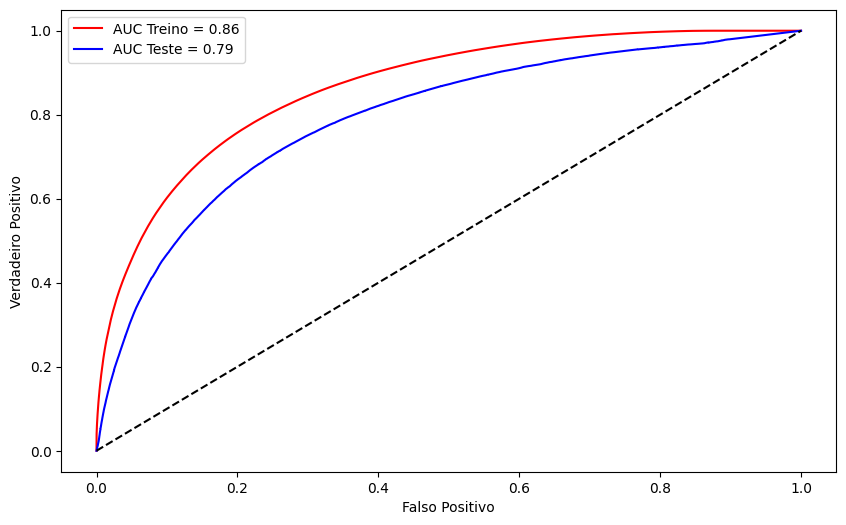

In [151]:
plt.figure(figsize=(10, 6))
plt.plot(fpr_train, tpr_train, color='red', label=f'AUC Treino = {auc_train:.2f}')
plt.plot(fpr_test, tpr_test, color='blue', label=f'AUC Teste = {auc_test:.2f}')
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlabel('Falso Positivo')
plt.ylabel('Verdadeiro Positivo')
#plt.title('Curva ROC')
plt.legend()
plt.show()

### Otimizador RandomizedSearchCV

### Carregar melhor random forest

In [ ]:
#Melhor modelo com todos os dados
#with open('G:\\Meu Drive\\ciencia de dados\\Pos\\TCC\\TCC\\random_forest_final.pkl', 'rb') as file:
#    final_clf = pickle.load(file)

### Treino modelo RandomizedSearchCV

In [ ]:
# #%% Definir o espaço de hiperparâmetros para Random Forest
# param_dist = {
#     'n_estimators': [50, 100, 200, 300],  # Número de árvores
#     'max_depth': range(2, 30, 1),      # Profundidade máxima das árvores
#     'min_samples_split': [2, 5, 10],      # Número mínimo de amostras para dividir um nó
#     'min_samples_leaf': [1, 2, 4],        # Número mínimo de amostras em uma folha
#     'max_features': ['sqrt', 'log2', None],  # Número de features consideradas para divisão (a raiz da amostra ou log da amostra)
#     'bootstrap': [True, False],           # Usar bootstrap ou não
#     'criterion': ['gini', 'entropy'],     # Critério de divisão
#     'ccp_alpha': np.linspace(0, 0.05, 20)  # Parâmetro de poda de complexidade de custo
# }

In [ ]:
# kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [ ]:
# #%% Configurar o RandomizedSearchCV
# n_iter = 50  # Número de combinações de hiperparâmetros a serem testadas
# kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-Fold estratificado
# random_search = RandomizedSearchCV(
#     estimator=RandomForestClassifier(random_state=42),
#     param_distributions=param_dist,
#     n_iter=n_iter, #Quantidade de Interações
#     cv=kf, #Estratégia de validação cruzada definido anterioremente
#     scoring='roc_auc',
#     n_jobs=-1,  # Usar todos os núcleos do processador
#     verbose=1,  # Mostrar progresso
#     random_state=42
# )

In [ ]:
# random_search.fit(X_train_dum, y_train)


In [ ]:
# print(f"\nMelhores hiperparâmetros: {random_search.best_params_}")
# print(f"\nAUC média na validação cruzada: {random_search.best_score_:.4f}")

In [ ]:
#%% Treinar o modelo final com os melhores hiperparâmetros
# final_clf = random_search.best_estimator_ #treina a arvores com os melhores parametros

### Avaliando modelo com RandomizedSearch

In [ ]:
# Probabilidades da classe positiva
# y_probs_rf_best = final_clf.predict_proba(X_test_dum)[:, 1]

In [ ]:
# Previsões binárias (threshold = 0.5)
# y_pred_rf_best = (y_probs_rf_best >= 0.5).astype(int)

In [ ]:
# # Determinando medidas de desempenho do modelo
# acuracia_rf_best = accuracy_score(y_test, y_pred_rf_best)
# precisao_rf_best = precision_score(y_test, y_pred_rf_best)
# acuracia_balanceada_rf_best = balanced_accuracy_score(y_test, y_pred_rf_best)
# auc_rf_best = roc_auc_score(y_test, y_probs_rf_best)
# gini_rf_best = 2 * auc_rf_best - 1

In [ ]:
# # Adicionando medidas de desempenho no dict_modelos
# dict_modelos['Modelo'].append('Random Forest Best')
# dict_modelos['Acuracia'].append(acuracia_rf_best)
# dict_modelos['Acuracia Balanceada'].append(acuracia_balanceada_rf_best)
# dict_modelos['AUC'].append(auc_rf_best)
# dict_modelos['GINI'].append(gini_rf_best)

In [ ]:
# dict_modelos

### Curva ROC Random Forest com otimizador RandomizedSearchCV

In [ ]:
# search_fpr_rf, search_tpr_rf, search_thresholds_rf = roc_curve(y_test, y_probs_rf_best)

In [ ]:
# search_fpr_rf, search_tpr_rf, search_thresholds_rf = roc_curve(y_test, y_probs_rf_best)

# # Plotar a Curva ROC
# plt.figure(figsize=(8, 6))
# plt.plot(search_fpr_rf, search_tpr_rf, color='blue', label=f'Curva ROC (AUC = {auc_rf_best:.2f})')
# plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Linha de referência (modelo aleatório)
# plt.xlabel("Taxa de Falsos Positivos (FPR)")
# plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
# plt.title(f"Curva ROC - Random Forest")
# plt.legend(loc="lower right")
# plt.grid()
# plt.show()

### Salvando melhor modelo

In [ ]:
# #Importância das variáveis baseada na diminuição da impureza do nó.
# explainer_rf = shap.TreeExplainer(modelo_rf)
# shap_values_rf = explainer_rf.shap_values(X_test_dum)
# shap.summary_plot(shap_values_rf, X_test_dum, feature_names=X_test_dum.columns, plot_type="bar")

### Otimizador Bayes Search

Para entender a otimização BayesSearch, é necessário ter noções de inferência bayesiana e de processos gaussianos.

A inferência bayesiana é um método estatístico que atualiza as probabilidades sobre um evento ou parâmetro à medida que novos dados são observadas. 
$$P(A|B)=\frac{P(B|A)\cdot P(A)}{P(B)}$$

onde, 


* $P(A|B)$ $\rightarrow$ Probabilidade posterior (crença atualizada após ver os dados).   
* $P(B|A)$ $\rightarrow$ Verossimilhança (probabilidade dos dados dado o modelo).   
* $P(A)$ $\rightarrow$ Probabilidade prior (crença inicial).
* $P(B)$ $\rightarrow$ Probabilidade marginal dos dados (normalização).


Por exemplo, para calcular qual é a probabilidade de uma pessoa ter uma doença após testar positivo, sabendo que 1% da população tem a doença, a chance de testar positivo caso a pessoa tenha a doença seja de 95% e a probabilidade total de testar positivo, mesmo os falso positivos.

* $P(B|A)=0.95$. Chance de positivo se estiver doente
* $P(A)=0.01$. Prevalença da doença na população
* $P(B)=0.95\cdot 0.01+ 0.05 \cdot 0.99$. Probabilidade total de testar positivo (incluindo falsos positivos) Probabilidade de testar positivo estando positivo ou probabilidade de testar positivo não estando positivo.




Processos Gaussianos fornecem previsões com incerteza,  são métodos não paramétricos e probabilístico usado em aprendizado de máquina e estatística para modelar funções desconhecidas.

Por exemplo, para prever a temperatura ao longo de um dia, suponha que você tenha algumas medições em certos horários (dados observados). Um Processo Gaussiano fornece não apenas uma previsão pontual, mas uma distribuição de probabilidade para a temperatura em qualquer horário futuro, considerando a incerteza.



A combinação de inferência bayesiana com processos gaussianos gera a técnica de otimização de hiperparâmetros chamada de BayesSearch.

Essa técnica combina inferência bayesiana e processos gaussianos para encontrar os melhores parâmetros de forma eficiente.

Comparada com Grid Search ou Random Search, essa técnica requer menos avaliações, pois prioriza regiões promissoras.

In [154]:
pip install skopt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement skopt (from versions: none)
ERROR: No matching distribution found for skopt


In [156]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

In [159]:
len(X_train.columns)

14

In [162]:
# Espaço de busca para os hiperparâmetros
param_space = {
    'n_estimators': Integer(100, 500),  # Número de árvores
    'max_depth': Integer(5,50),       # Profundidade máxima
    'max_features': Real(0.5, 0.9, 'uniform'),  # Número de features consideradas
    'min_samples_split': Integer(2, 50),  # Mínimo de amostras para dividir um nó
    'min_samples_leaf': Integer(1, 30),    # Mínimo de amostras em uma folha
    'bootstrap': Categorical([True, False]),  # Usar amostragem bootstrap?
    'criterion': Categorical(['gini', 'entropy']),  # Critério de divisão
    'class_weight': Categorical(['balanced', 'balanced_subsample', None]), # Balanceamento de classes
    'ccp_alpha': Real(0.0, 0.01, 'uniform')  # Penalidade de complexidade
}

In [166]:
import multiprocessing
total_cores = multiprocessing.cpu_count()
ninety_percent_cores = int(total_cores * 0.9)

In [177]:
# Definir a busca Bayesiana
total_cores = multiprocessing.cpu_count()
ninety_percent_cores = int(total_cores * 0.9)

busca_bayes = BayesSearchCV(
    estimator=modelo_rf,
    search_spaces=param_space,
    n_iter=50,  # Número de iterações (combinações testadas)
    cv=5,       # Número de folds na validação cruzada
    scoring='roc_auc',  # Métrica de avaliação (pode ser 'accuracy', 'f1', etc.)
    n_jobs=total_cores,  # Usar todos os núcleos do CPU
    random_state=42,
    verbose=0   # Mostrar progresso
)

In [178]:
busca_bayes.fit(X_train_dum, y_train)


,estimator,RandomForestC...ndom_state=42)
,search_spaces,"{'bootstrap': Categorical(c...), prior=None), 'ccp_alpha': Real(low=0.0,...m='normalize'), 'class_weight': Categorical(c...), prior=None), 'criterion': Categorical(c...), prior=None), ...}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'roc_auc'
,fit_params,None
,n_jobs,28
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [179]:
melhor_modelo_random_bayes = busca_bayes.best_estimator_

In [185]:
import pickle
with open('G:\\Meu Drive\\ciencia de dados\\Pos\\TCC\\TCC\\melhor_modelo_random_bayes.pkl', 'wb') as f:
    pickle.dump(melhor_modelo_random_bayes, f)

In [ ]:
print(f"Melhores parâmetros: {busca_bayes.best_params_}")
print(f"Melhor score: {busca_bayes.best_score_}") # Melhor score (AUC-ROC no caso)

Melhores parâmetros: OrderedDict({'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 49, 'max_features': 0.5, 'min_samples_leaf': 30, 'min_samples_split': 11, 'n_estimators': 500})
Melhor score: 0.8147363917315256


Durante o BayesSearchCV, vários modelos são testados com diferentes combinações de hiperparâmetros.
O best_estimator_ é a melhor versão do modelo, RandomForest, com os parâmetros que obtiveram o melhor desempenho, nesse caso, medido por roc_auc.

In [186]:
# Fazer previsões no teste com o melhor modelo
y_pred_proba_bayes = busca_bayes.predict_proba(X_test_dum)[:, 1]
auc_test_bayes = roc_auc_score(y_test, y_pred_proba_bayes)
print(f"AUC-ROC no teste: {auc_test_bayes:.4f}")

AUC-ROC no teste: 0.8146


In [188]:
# Probabilidades da classe positiva
y_probs_rf_bayes = melhor_modelo_random_bayes.predict_proba(X_test_dum)[:, 1]

In [189]:
# Previsões binárias (threshold = 0.5)
y_pred_rf_bayes = (y_probs_rf_bayes >= 0.5).astype(int)

In [190]:
y_pred_rf_bayes

array([0, 0, 0, ..., 0, 0, 1], shape=(433369,))

In [191]:
# Determinando medidas de desempenho do modelo
acuracia_rf_bayes = accuracy_score(y_test, y_pred_rf_bayes)
precisao_rf_bayes = precision_score(y_test, y_pred_rf_bayes)
acuracia_balanceada_rf_bayes = balanced_accuracy_score(y_test, y_pred_rf_bayes)
auc_rf_bayes = roc_auc_score(y_test, y_probs_rf_bayes)
gini_rf_bayes = 2 * auc_rf_bayes - 1

In [192]:
# Adicionando medidas de desempenho no dict_modelos
dict_modelos['Modelo'].append('Random Forest Bayes')
dict_modelos['Acuracia'].append(acuracia_rf_bayes)
dict_modelos['Acuracia Balanceada'].append(acuracia_balanceada_rf_bayes)
dict_modelos['AUC'].append(auc_rf_bayes)
dict_modelos['GINI'].append(gini_rf_bayes)

In [193]:
pd.DataFrame(dict_modelos)

,Modelo,Acuracia,Acuracia Balanceada,AUC,GINI
0,1ª Random Forest,0.822112,0.648628,0.792279,0.584557
1,Random Forest Bayes,0.828206,0.641333,0.814639,0.629277


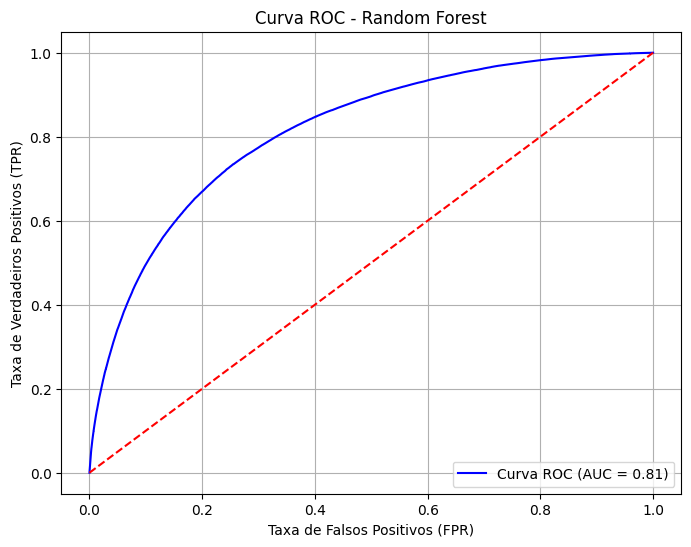

In [194]:
bayes_fpr_rf, bayes_tpr_rf, bayes_thresholds_rf = roc_curve(y_test, y_probs_rf_bayes)

# Plotar a Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(bayes_fpr_rf, bayes_tpr_rf, color='blue', label=f'Curva ROC (AUC = {auc_rf_bayes:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Linha de referência (modelo aleatório)
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title(f"Curva ROC - Random Forest")
plt.legend(loc="lower right")
plt.grid()
plt.show()

### Agrupamento das Variáveis One-Hot

In [195]:
colunas_renda = [col for col in presentes_df_enem_2023_dummies.columns if "RENDA".lower() in col.lower()]
colunas_faixa = [col for col in presentes_df_enem_2023_dummies.columns if "ETARIA".lower() in col.lower()]
colunas_regiao = [col for col in presentes_df_enem_2023_dummies.columns if "REGIAO".lower() in col.lower()]
colunas_paterna = [col for col in presentes_df_enem_2023_dummies.columns if "PATERNA".lower() in col.lower()]
colunas_materna = [col for col in presentes_df_enem_2023_dummies.columns if "MATERNA".lower() in col.lower()]




In [196]:
colunas_dummies=['FAIXA_ETARIA', 
                'SEXO', 
                'COR', 
                'NACIONALIDADE',
                'REGIAO',       
                'ADM_ESC', 
                'TP_URBANA_RURAL', 
                'ESCOLARIDADE_PATERNA',       
                'ESCOLARIDADE_MATERNA', 
                'RENDA_FAMILIAR']

In [197]:
presentes_df_enem_2023_dummies.columns

Index(['INSCRICAO', 'IS_TOP20', 'FAIXA_ETARIA_18', 'FAIXA_ETARIA_19',
       'FAIXA_ETARIA_20', 'FAIXA_ETARIA_21', 'FAIXA_ETARIA_22',
       'FAIXA_ETARIA_23', 'FAIXA_ETARIA_24', 'FAIXA_ETARIA_25',
       'FAIXA_ETARIA_26_30', 'FAIXA_ETARIA_31_35', 'FAIXA_ETARIA_36_40',
       'FAIXA_ETARIA_41_45', 'FAIXA_ETARIA_46_50', 'FAIXA_ETARIA_51_55',
       'FAIXA_ETARIA_56_60', 'FAIXA_ETARIA_61_65', 'FAIXA_ETARIA_66_70',
       'FAIXA_ETARIA_maior_que_70', 'FAIXA_ETARIA_menor_que_17',
       'SEXO_Masculino', 'COR_Branca', 'COR_Indígena', 'COR_Nao_declarado',
       'COR_Parda', 'COR_Preta',
       'NACIONALIDADE_Brasileiro_Nato_nascido_no_exterior',
       'NACIONALIDADE_Brasileiro_Naturalizado', 'NACIONALIDADE_Estrangeiro',
       'NACIONALIDADE_Nao_informado', 'REGIAO_Nordeste', 'REGIAO_Norte',
       'REGIAO_Sudeste', 'REGIAO_Sul', 'REGIAO_Desconhecido',
       'ADM_ESC_Privada', 'ADM_ESC_Publica', 'ADM_ESC_Desconhecido',
       'TP_URBANA_RURAL_urbana', 'TP_URBANA_RURAL_Desconhecido',
   

In [198]:
# Cria um dict para agergar as colunas one-hot para a variável original
var_original = {
    'FAIXA_ETARIA': colunas_faixa, 
    'SEXO': ['SEXO_Masculino'], 
    'COR':['COR_Branca', 'COR_Indígena', 'COR_Nao_declarado', 'COR_Parda', 'COR_Preta'], 
    'NACIONALIDADE': ['NACIONALIDADE_Brasileiro_Nato_nascido_no_exterior', 'NACIONALIDADE_Brasileiro_Naturalizado', 'NACIONALIDADE_Nao_informado'] ,
    'REGIAO': colunas_regiao,       
    'ADM_ESC': ['ADM_ESC_Privada', 'ADM_ESC_Publica', 'ADM_ESC_Desconhecido'], 
    'TP_URBANA_RURAL': ['TP_URBANA_RURAL_Desconhecido'], 
    'ESCOLARIDADE_PATERNA': colunas_paterna,       
    'ESCOLARIDADE_MATERNA':colunas_materna, 
    'RENDA_FAMILIAR': colunas_renda   
}


### Shap Agregado

In [ ]:
explainer_rf_bayes = shap.TreeExplainer(modelo_rf_bayes)

In [ ]:
shap_values_rf_bayes = explainer_rf_bayes.shap_values(X_test_dum)
shap_values_rf_bayes


In [ ]:
# Calcula a contribuição agregada por variável original
shap_agregado = {}
for var, cols in var_original.items():
    idx = [X_test_dum.columns.get_loc(c) for c in cols] #Enconta o index de cada 
    shap_agregado[var] = np.sum(np.abs(shap_values_rf_bayes).mean(0)[idx])


In [ ]:
shap_agregado

In [ ]:
dict(sorted(shap_agregado.items(), key=lambda item: item[1], reverse=True))

### Feature Importances Agregado

Importância das variáveis baseada na diminuição da impureza do nó.


In [ ]:
features = list(X_train_dum)
feature_importances = modelo_rf_bayes.feature_importances_
importances = pd.DataFrame(index=features)
importances['importance'] = feature_importances
importances['rank'] = importances['importance'].rank(ascending=False).values
importances.sort_values('rank').head(10)

In [ ]:
# Calcula a contribuição agregada por variável original
feature_importances_agregado = {}
for var, cols in var_original.items():
    idx = [X_test_dum.columns.get_loc(c) for c in cols] #Enconta o index de cada
    feature_importances_agregado[var] = np.sum(feature_importances[idx])


In [ ]:
feature_importances_agregado

In [ ]:
dict(sorted(feature_importances_agregado.items(), key=lambda item: item[1], reverse=True))

## LightGBM


In [ ]:
#pip install scikit-optimize

In [ ]:
import lightgbm as lgbm
from skopt import BayesSearchCV

### Otimizador BayesSearch

In [ ]:
# Criando um classificador base
lgbm_clf = lgbm.LGBMClassifier(boosting_type='gbdt', 
                               objective='binary', 
                               random_state=42)

In [ ]:
# Criando o espaço de busca para o otimizador
param_grid = {
    'num_leaves': (20, 21),  # Número de folhas na árvore de decisão
    'max_depth': (3, 15),  # Profundidade máxima da árvore
    'learning_rate': (0.01, 0.3, 'log-uniform'),  # Taxa de aprendizado
    'n_estimators': (1, 3),  # Número de árvores
    'subsample': (0.5, 1.0),  # Proporção de amostras usadas em cada árvore
    'colsample_bytree': (0.5, 1.0),  # Fração de colunas a serem usadas por árvore
    'reg_alpha': (1e-5, 1.0, 'log-uniform'),  # Regularização L1
    'reg_lambda': (1e-5, 1.0, 'log-uniform'),  # Regularização L2
}

In [ ]:
# Criando o otimizador Bayesiano
bayes_search = BayesSearchCV(
    estimator=lgbm_clf,  # Modelo a ser otimizado
    search_spaces=param_grid,  # Espaço de busca definido acima
    scoring='roc_auc',  # Critério de seleção: Área sob a curva ROC (AUC)
    n_iter=10,  # Número de avaliações do modelo
    cv=3,  # Validação cruzada com 5 folds
    random_state=42,
    n_jobs=-1,  # Paralelização total dos cálculos
    verbose=0
)


In [ ]:
X_train.columns

### Treinando o modelo

Será treinado o modelo com os melhores parâmetros escolhido pelo otimizador Bayesiano, excluindo variáveis relacionados com a faixa de renda salarial ('POSSUI_DIARISTA', 'QTD_BANHEIROS', 'QTD_CARROS',
       'QTD_GELADEIRA', 'QTD_TV_COLORIDA', 'QTD_COMPUTADOR', 'ACESSO_INTERNET')

In [ ]:
# Treinando o modelo
bayes_search.fit(X_train, y_train)

In [ ]:
# Melhores estimadores usando o otimizador Bayes
best_model_bayes = bayes_search.best_estimator_
best_model_bayes


### Avaliando o modelo com melhores parâmetros

In [ ]:
# Probabilidades da classe positiva
y_probs_lgbm = best_model_bayes.predict_proba(X_test)[:, 1]

In [ ]:
# Previsões binárias (threshold = 0.5)
y_pred_lgbm = (y_probs_lgbm >= 0.5).astype(int)

In [ ]:
# Determinando medidas de desempenho do modelo
acuracia_lgbm = accuracy_score(y_test, y_pred_lgbm)
precisao_lgbm = precision_score(y_test, y_pred_lgbm)
acuracia_balanceada_lgbm = balanced_accuracy_score(y_test, y_pred_lgbm)
auc_lgbm = roc_auc_score(y_test, y_probs_lgbm)
gini_lgbm = 2 * auc_lgbm - 1


In [ ]:
# Adicionando medidas de desempenho no dict_modelos
dict_modelos['Modelo'].append('LightGBM Bayes')
dict_modelos['Acuracia'].append(acuracia_lgbm)
dict_modelos['Acuracia Balanceada'].append(acuracia_balanceada_lgbm)
dict_modelos['AUC'].append(auc_lgbm)
dict_modelos['GINI'].append(gini_lgbm)

In [ ]:
dict_modelos

### Curva Roc LightGBM

In [ ]:
bayes_fpr_lgbm, bayes_tpr_lgbm, bayes_thresholds_lgbm = roc_curve(y_test, y_probs_lgbm)

# Plotar a Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(bayes_fpr_lgbm, bayes_tpr_lgbm, color='blue', label=f'Curva ROC (AUC = {auc_lgbm:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Linha de referência (modelo aleatório)
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title(f"Curva ROC - Random Forest")
plt.legend(loc="lower right")
plt.grid()
plt.show()

### Importância das variáveis

In [ ]:
importance_lgbm = best_model_bayes.feature_importances_
importance_lgbm


In [ ]:
lgbm.plot_importance(best_model_bayes, importance_type="gain", figsize=(7,6), title="LightGBM Feature Importance (Gain)")
plt.show()

In [ ]:
lgbm.plot_importance(best_model_bayes, importance_type="split", figsize=(7,6), title="LightGBM Feature Importance (Split)")
plt.show()

### SHAP

In [ ]:
import shap

In [ ]:
explainer_lgbm = shap.TreeExplainer(best_model_bayes)

In [ ]:
shap_values_lgbm = explainer_lgbm(X_test.drop(columns=['POSSUI_DIARISTA', 'QTD_BANHEIROS', 'QTD_CARROS',
       'QTD_GELADEIRA', 'QTD_TV_COLORIDA', 'QTD_COMPUTADOR', 'ACESSO_INTERNET']))

In [ ]:
shap.summary_plot(shap_values_lgbm, X_test.drop(columns=['POSSUI_DIARISTA', 'QTD_BANHEIROS', 'QTD_CARROS', 'QTD_GELADEIRA', 'QTD_TV_COLORIDA', 'QTD_COMPUTADOR', 'ACESSO_INTERNET']))


In [ ]:
print("Mínimo SHAP:", np.min(shap_values_lgbm.values))
print("Máximo SHAP:", np.max(shap_values_lgbm.values))

## XGBoosting

In [ ]:
import xgboost as xgb
from xgboost import plot_importance


### Treinando o modelo

In [ ]:
colunas=X.columns.to_list()
colunas

### Otimizador BayesSearch

In [ ]:
# Espaço de busca para os hiperparâmetros para otimização bayesiana
param_space_bayes_xgb = {'learning_rate': (0.01, 0.3, 'log-uniform'),
    'max_depth': (3, 10),
    'min_child_weight': (1, 10),
    'subsample': (0.5, 1.0),
    'colsample_bytree': (0.5, 1.0),
    'gamma': (0, 0.5),
    'n_estimators': (50, 300),
    'reg_alpha': (0, 10),
    'reg_lambda': (0, 10)
}

In [ ]:
# Criar o modelo XGBoost
xgb_model_bayes = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, enable_categorical=True,
    tree_method='hist')

# tree_method='hist' -> Necessário para enable_categorical
# enable_categorical=True -> Habilita suporte a categorias

In [ ]:
# Configurar o Bayesian Search
otimizador_bayes = BayesSearchCV(
    estimator=xgb_model_bayes,
    search_spaces=param_space_bayes_xgb,
    n_iter=50,  # Número de iterações de otimização
    cv=5,       # Número de folds na validação cruzada
    n_jobs=-1,  # Usar todos os cores disponíveis
    random_state=42,
    verbose=1
)

In [ ]:
# Executar a otimização
otimizador_bayes.fit(X_train, y_train)

In [ ]:
# Melhores parâmetros encontrados
print("Melhores parâmetros encontrados: ", otimizador_bayes.best_estimator_)

### Avaliando o modelo

In [ ]:
# Probabilidades da classe positiva
y_probs_xg_test_bayes= otimizador_bayes.predict_proba(X_test)[:, 1]
y_probs_xg_train_bayes= otimizador_bayes.predict_proba(X_train)[:, 1]

In [ ]:
# Fazer previsões com o melhor modelo (Considerando threshold=0.5)
y_pred_xg_bayes = otimizador_bayes.predict(X_test)
y_pred_xg_bayes

In [ ]:
# Determinando medidas de desempenho do modelo
acuracia_xg_bayes = accuracy_score(y_test, y_pred_xg_bayes)
precisao_xg_bayes= precision_score(y_test, y_pred_xg_bayes)
acuracia_balanceada_xg_bayes = balanced_accuracy_score(y_test, y_pred_xg_bayes)
auc_xg_test_bayes = roc_auc_score(y_test, y_probs_xg_test_bayes)
auc_xg_train_bayes = roc_auc_score(y_train, y_probs_xg_train_bayes)
gini_xg_bayes = 2 * auc_xg_test_bayes - 1

In [ ]:
# Adicionando medidas de desempenho no dict_modelos
dict_modelos['Modelo'].append('XGBoost - Bayes')
dict_modelos['Acuracia'].append(acuracia_xg_bayes)
dict_modelos['Acuracia Balanceada'].append(acuracia_balanceada_xg_bayes)
dict_modelos['AUC'].append(auc_xg_bayes)
dict_modelos['GINI'].append(gini_xg_bayes)

In [ ]:
pd.DataFrame(dict_modelos)

### Curva ROC - XgBoost - Otimizador Bayesiano

In [ ]:
bayes_fpr_test_xg_bayes, bayes_tpr_test_xg_bayes, bayes_thresholds_test_xg_bayes = roc_curve(y_test, y_probs_xg_test_bayes)
bayes_fpr_train_xg_bayes, bayes_tpr_train_xg_bayes, bayes_thresholds_train_xg_bayes = roc_curve(y_train, y_probs_xg_train_bayes)

# Plotar a Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(bayes_fpr_test_xg_bayes, bayes_tpr_test_xg_bayes, color='blue', label=f'Curva ROC (AUC = {auc_xg_test_bayes:.2f})')
plt.plot(bayes_fpr_train_xg_bayes, bayes_tpr_train_xg_bayes, color='red', label=f'AUC Treino = {auc_xg_train_bayes:.2f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Linha de referência (modelo aleatório)
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title(f"Curva ROC - Random Forest")
plt.legend(loc="lower right")
plt.grid()
plt.show()

### Importância das variáveis

In [ ]:
modelo_xg_bayes=otimizador_bayes.best_estimator_

In [ ]:
# Ver os tipos de importância disponíveis
melhores_features_xg_bayes_weight=modelo_xg_bayes.get_booster().get_score(importance_type='weight')
melhores_features_xg_bayes_gain=modelo_xg_bayes.get_booster().get_score(importance_type='gain')
melhores_features_xg_bayes_cover=modelo_xg_bayes.get_booster().get_score(importance_type='cover')

In [ ]:
# Plotar importância baseada no ganho (mais comum)
plt.figure(figsize=(10, 8))
plot_importance(modelo_xg_bayes, importance_type='gain', max_num_features=20)
plt.title('Importância das Variáveis - Ganho')
plt.show()

In [ ]:
# Plotar importância baseada no peso (frequência)
plt.figure(figsize=(10, 8))
plot_importance(modelo_xg_bayes, importance_type='weight', max_num_features=20)
plt.title('Importância das Variáveis - Frequência')
plt.show()

In [ ]:
# Plotar importância baseada no cover
plt.figure(figsize=(10, 8))
plot_importance(modelo_xg_bayes, importance_type='cover', max_num_features=20)
plt.title('Importância das Variáveis - Frequência')
plt.show()

### Shapley

In [ ]:
import shap
shap.initjs()

In [ ]:
explainer_xg = shap.TreeExplainer(modelo_xg_bayes)

In [ ]:
explanation_xg = explainer_xg(X_test)


In [ ]:
print(explanation_xg)

In [ ]:
shap_features=explanation_xg.feature_names

In [ ]:
shap_values = explanation_xg.values
shap_values

In [ ]:
#Qual impacto cada variável tem na saída do modelo para indivíduos no conjunto de dados de validação
shap.plots.beeswarm(explanation_xg)

Observe que RENDA_FAMILIAR é a variável com a maior importância, indicando que a renda familiar tem um impacto significativo na análise realizada. Isso sugere que questões socioeconômicas são determinantes no contexto estudado.

A segunda variável mais importante é SEXO, isto pode indicar diferenças significativas entre gêneros nos dados analisados.

QTD_CARROS: Também tem relevância considerável, possivelmente relacionada ao poder aquisitivo ou estilo de vida.

In [ ]:
shap.summary_plot(shap_values, X, plot_type="bar")